# Brendan Quinn - 21315205, Milan Kovacs - 21308128
## The app runs to completion

# The Dataset


We are using Vegetable Image Dataset (https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset) from Kaggle.

The dataset contains 15 classes with 15,000 Training images, 3,000 Validation images and 3,000 testing images.

We are going to extract the images, get a few samples.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix
import os.path
from keras import utils
import keras
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import kagglehub
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.applications import vgg16
from google.colab import drive
import pickle
from tensorflow.keras import Model
from tensorflow.keras.applications import InceptionV3
drive.mount('/content/drive')
print("Imported all the libraries")

Mounted at /content/drive
Imported all the libraries


In [ ]:
# Load Data
download_path = "/root/.cache/kagglehub/datasets/misrakahmed/"
os.makedirs(download_path, exist_ok=True)
print("Dir made")

Dir made


In [ ]:
# Check if dataset is downloaded
if not os.path.exists(os.path.join(download_path, "vegetable-image-dataset")):
    download_path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")
    download_path = os.path.join(download_path, "Vegetable Images")
    print("Dataset Downloaded")
else:
    download_path = os.path.join(download_path, "vegetable-image-dataset", "versions", "1", "Vegetable Images") # Path to dataset
    print("Dataset already downloaded")

print("Path to dataset files:", download_path)
print("The path contains the following folders:", os.listdir(download_path))

100%|██████████| 534M/534M [00:02<00:00, 261MB/s]

Extracting files...


Dataset Downloaded
Path to dataset files: /root/.cache/kagglehub/datasets/misrakahmed/vegetable-image-dataset/versions/1/Vegetable Images
The path contains the following folders: ['train', 'validation', 'test']


In [ ]:
# Constants
IMG_SIZE = (224, 224)
INPUT_SHAPE = IMG_SIZE + (3,) # VGG input shape

INCEPTION_IMG_SIZE = (299, 299)
INCEPTION_INPUT_SHAPE = INCEPTION_IMG_SIZE + (3,)

BATCH_SIZE = 64
SEED = 42

LABEL_MODE = "categorical"
LABLES_TYPE = "inferred" # We will label the images from the name of the directory

np.random.seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE # This lets the hardware pre-fetch data in whatever size it can handle https://www.tensorflow.org/guide/data_performance

print("Constants are loaded")

Constants are loaded


In [ ]:
# Iterators for training, test and validation datasets

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{download_path}/train",
    labels=LABLES_TYPE,
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{download_path}/test",
    labels=LABLES_TYPE,
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{download_path}/validation",
    labels=LABLES_TYPE,
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(CLASS_NAMES)

Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


In [ ]:
# For image display we wont shuffle (so we can get deterministic images):
train_ds_no_shuffle = tf.keras.utils.image_dataset_from_directory(
    f"{download_path}/train",
    labels=LABLES_TYPE,
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    image_size=IMG_SIZE,
    shuffle=False, # No Shuffle
    seed=SEED
)

Found 15000 files belonging to 15 classes.


In [ ]:
# print test_ds shape
for image_batch, labels_batch in test_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(64, 224, 224, 3)
(64, 15)


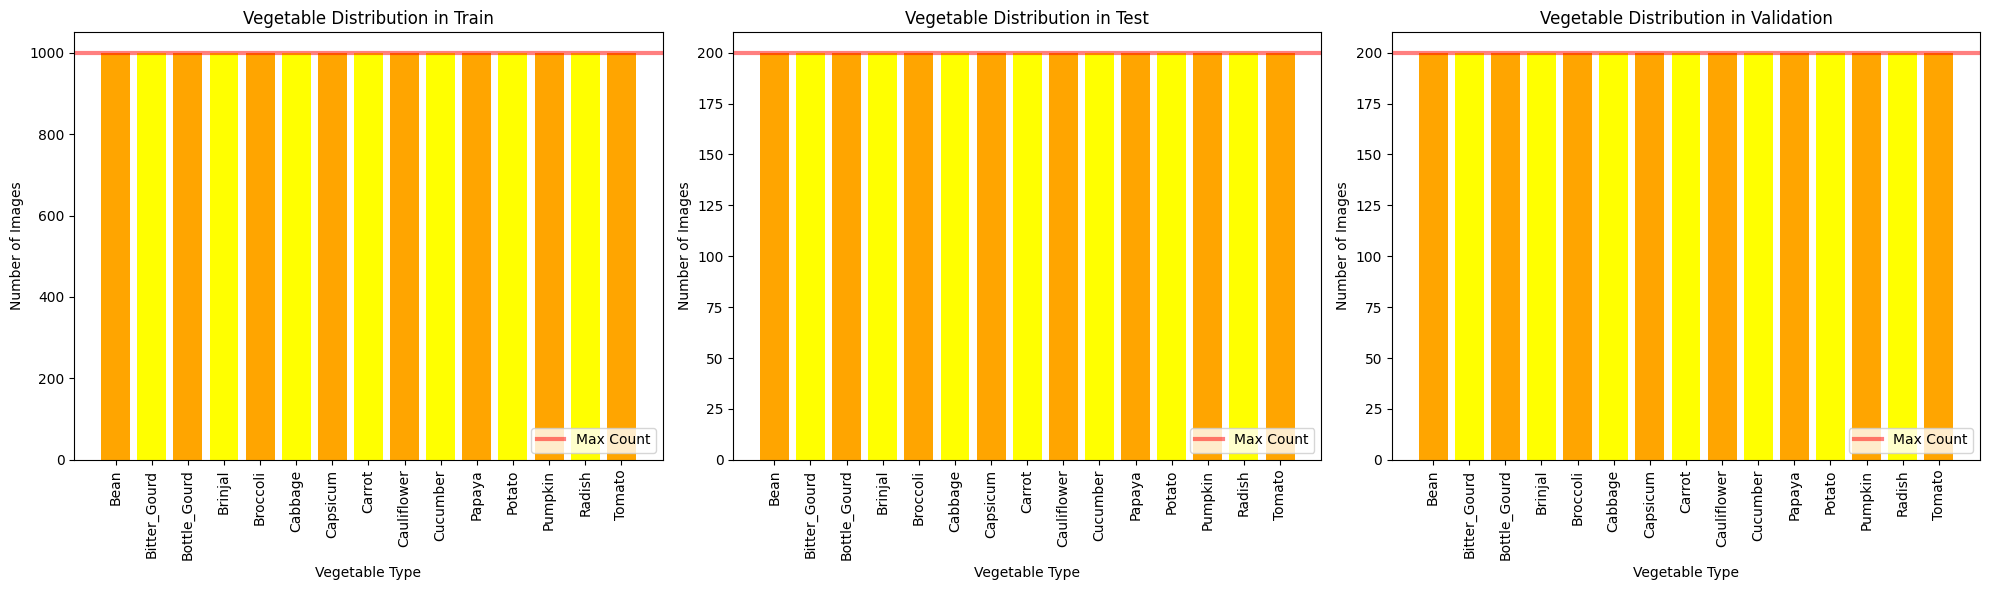

In [ ]:
# Bar chart
fig, axis = plt.subplots(1,3)
fig.set_figheight(6)
fig.set_figwidth(20)

vegetable_types = set() # We will have a set where we will store a single instance of each vegetable

dataset_groups = {"Train": train_ds, "Test": test_ds, "Validation": val_ds} # Merge all iterators into a single dict

for index, (set_name, dataset) in enumerate(dataset_groups.items()):
    # Collect the labels for the current dataset
    all_labels = []
    for images, labels in dataset_groups[set_name]:
        # Convert one-hot encoded labels to class indices using argmax
        class_indices = [np.argmax(label) for label in labels.numpy()]
        all_labels.extend(class_indices) # Append to the array

    vegetables_counts = Counter(all_labels) # Sum the occurrences of classification

    # Sort the vegetable count keys based on the alphabetical correspondence in class names
    sorted_classes = sorted(vegetables_counts.keys(), key=lambda x: CLASS_NAMES[x])

    # Map the vegetable_counts to match the order of sorted classifications
    sorted_counts = [vegetables_counts[i] for i in sorted_classes]

    # Map the names onto the classifications
    sorted_class_names = [CLASS_NAMES[i] for i in sorted_classes]

    plot = axis[index] # Take the plot for the iteration
    plot.title.set_text(set_name)

    # X axis is the class names, the Y axis is the number of occurences, with alternating colours
    plot.bar(sorted_class_names, sorted_counts, color=['orange', 'yellow'])
    x_axis = plot.get_xticklabels()
    plot.tick_params(axis='x',  labelsize=10, labelrotation=90)
    plot.set(xlabel = 'Vegetable Type', ylabel='Number of Images', title=f"Vegetable Distribution in {set_name}")

    # Place a red line for the highest elemet count
    max_count = max(vegetables_counts.values())
    plot.axhline(y=max_count, color='red', linestyle='-', label='Max Count', linewidth=3, alpha=0.5)

    plot.legend(loc='lower right')

plt.tight_layout()

plt.show()

## The images


We can see there is a variety of images with different background elements. Our models need to be able to detect the main object(s) in order to correctly classify.

In [ ]:
# Sample images
sample_images = {} # Dictionary for class -> image

for images, labels in train_ds_no_shuffle:
  for image, label in zip(images, labels):
    label_index = np.argmax(label) # One-hot -> index
    label_name = CLASS_NAMES[label_index] # Take the name for the index

    if label_name not in sample_images:
      sample_images[label_name] = image.numpy()

      if len(sample_images) == NUM_CLASSES: # If we have 15 images, we can exit
        break
  if len(sample_images) == NUM_CLASSES:
    break

print("sample_images is populated!")

# Plot the images in 5 rows, 3 columns
fig, axis = plt.subplots(5, 3)
fig.set_figheight(40)
fig.set_figwidth(35)
plt.subplots_adjust(hspace=0.2, wspace=0.0)

# For each item in the dictionary, we will enumerate through the index, (class, image)
for index, (class_name, image) in enumerate(sample_images.items()):
    plot = axis[index // 3, index % 3] # which cell will contain the image
    plot.imshow(image.astype("uint8"))
    plot.set_title(class_name, size=30)
    plot.axis("off")

plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Model 1: VGG16


VGG-16 is an architecture developed by the Visual Geometry Group at the University of Oxford. (pawangfg, 2024)

It consists of 16 Layers, of which 13 are convolution and 3 Fully connected layers. It was made popular due to its simplicity and performance on lower-end computers.

There are pretrained weights on ImageNet which we will be using. The ImageNet Large Scale Visual Recognition Challenge, is an annual competition for teams of CNN developers to compete in object localization and image classification. In 2014 VGG-16 came in the top rank with being able to detect images from 200 classes and classifying images into 1000 categories.

The Keras API lets allows you to download weights from ImageNet as seen in the code, and if you want to have the output layers (include_top) you have the option to have the 1,000 classifications.

pawangfg, 2024, GeeksForGeeks.com. https://www.geeksforgeeks.org/vgg-16-cnn-model/

## Architecture

The VGG16 has 13 Convolutions, 5 pooling layers and 3 Fully-connected layer.

Input layer: 224x224, 3 Channels
It has
- Two 64, 3x3 Convolutions
- Max Pooling of 2x2, Stride 2
- Two 128, 3x3 Convolutions
- Max Pooling of 2x2, Stride 2
- Three 256, 3x3 Convolutions
- Max Pooling of 2x2, Stride 2
- Three 512, 3x3 Colvolutions
- Max Pooling of 2x2, Stride 2
- Three 512, 3x3 Colvolutions
- Max Pooling of 2x2, Stride 2
- The three fully connected Layers
  - After flattening the output is (7x7x512) vector with a result of 25,088
  - First layer: Input 25,088 Output 4,096 (Fully connected 4,096)
  - Second Layer: Input 4,096 Output 4,096 (Fully connected 4,096)
  - Third Layer: Input 4,096 Output 1,000 Classifications (Fully conntected 1,000)
  - Softmax Layer

Note after we have trained the model, we have missed one layer. Was originally following Tammina's implementation from the paper citied below.

## Transfer Learning (Tammina, 2019)


Tammina in the paper from 2019 discusses training a VGG model from scratch vs transfer learning. Tammina took the pretrained model and froze the convolutions and dropped the fully connected. Then added two 4,096 fully connected layers mapped to two classifications between cats and dogs.

The model from scratch had a very poor performance on unseen data which was very similar when we tried to train the Yolo architecture. The training data had ~90% accuracy but validation was ~50%, and the loss was increasing with each epoch.

After reading this paper, we decided to take a take the trained weights of VGG16 and try and classify the 15 datasets. In our model, we will also have two fully connected layers of 4,096 and compare it against training on frozen convolutions VS unfrozen.

Image taken from (Tammina, 2019):  
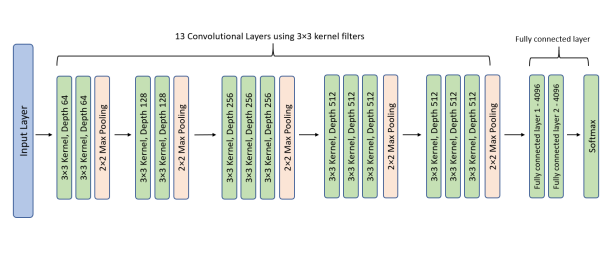


Tammina, Srikanth. (2019). Transfer learning using VGG-16 with Deep Convolutional Neural Network for Classifying Images. International Journal of Scientific and Research Publications (IJSRP). 9. p9420. 10.29322/IJSRP.9.10.2019.p9420.

## VGG16


The model taken from Keras API: https://keras.io/api/applications/vgg/#vgg16-function

In [ ]:
def create_vgg16_model(
                        learning_rate=0.001,
                        optimizer='adam',
                        activation='relu',
                        dropout_rate=0.5,
                        loss ='categorical_crossentropy',
                        frozen = True
) -> keras.models.Sequential:
    vgg_model = vgg16.VGG16(
      include_top=False,    # Excluding the fully connected layers
      weights="imagenet",   # Load pre-trained weights from ImageNet
      name="vgg16",
      input_shape=INPUT_SHAPE # The shape (size, size, channels)
    )

    # Frozen convolutions or not
    if frozen:
      for layer in vgg_model.layers:
          layer.trainable = False
    else:
      for layer in vgg_model.layers:
          layer.trainable = True


    # Add custom classification layers
    x = vgg_model.output
    x = GlobalAveragePooling2D()(x)   # Global pooling layer taken from https://stackoverflow.com/questions/44091023/how-to-use-pre-trained-features-from-vgg-16-as-input-to-globalaveragepooling2d
                                      # After we completed training we figured we probably should've used flatten(), but the model ended up running fine
    x = Dense(4096, activation=activation, )(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(4096, activation=activation)(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(15, activation='softmax')(x)  # Final layer for 15 classes

    # Define the complete model
    model = Model(inputs=vgg_model.input, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

    return model

print("VGG16 Constructor made")

VGG16 Constructor made


## About the model


### Transfer Learning
We leveraged the transfer learning by using the weights on imagenet.

### Optimiser
For now we will try it with Adam optimizer, however later on we will be experimenting with different hyperparameters

### Loss Function
We will use Categorical Cross Entropy to categorize our classifications

### Metrics
We will be aiming for high accuracy

### The summary
You can see in the frozen convolutions, out of the 33M parameters only 14.7M is trainable. In the unfrozen all 33M is trainable.

In [ ]:
vgg = create_vgg16_model()
vgg_unfrozen = create_vgg16_model(frozen=False)
vgg.summary()
vgg_unfrozen.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_11          │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 4096)                │       2,101,2

 Total params: 33,658,703 (128.40 MB)

 Trainable params: 18,944,015 (72.27 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_12          │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 4096)                │       2,101,2

 Total params: 33,658,703 (128.40 MB)

 Trainable params: 33,658,703 (128.40 MB)

 Non-trainable params: 0 (0.00 B)

# Image Augmentation


In the paper of Tammina discusses the use of augmentation from their 2019 paper. He discusses that his model overfit after 3 epochs, so by adding some minor variations such as rotation, zooming, etc. We are not distoring the main subject of the images too much, however it makes the model be more robust to real-world scenarios. Thus it is more resilient to overfitting



Tammina, Srikanth. (2019). Transfer learning using VGG-16 with Deep Convolutional Neural Network for Classifying Images. International Journal of Scientific and Research Publications (IJSRP). 9. p9420. 10.29322/IJSRP.9.10.2019.p9420.

In [ ]:
# Taken from: https://www.researchgate.net/profile/Srikanth-Tammina/publication/337105858_Transfer_learning_using_VGG-16_with_Deep_Convolutional_Neural_Network_for_Classifying_Images/links/5dc94c3ca6fdcc57503e6ad9/Transfer-learning-using-VGG-16-with-Deep-Convolutional-Neural-Network-for-Classifying-Images.pdf?_sg%5B0%5D=started_experiment_milestone&origin=journalDetail&_rtd=e30%3D
"""
The following code was used in the paper, however it has now been
deprecated, we will convert it to a more modern pipeline.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode = 'nearest'
)

test_datagen = ImageGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
"""

# Sequential Augmentation applied to the data
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),                    # Random rotation by upto 36 degrees
    tf.keras.layers.RandomZoom(0.2),                        # Random zoom by upto 20% of image size
    tf.keras.layers.RandomTranslation(0.2, 0.2),            # Random translation of along upto 20% width and 20% height
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),  # Randomly flipping images horizontally and vertically
    tf.keras.layers.RandomContrast(0.2),                    # Random contrast adjusment of upto 20%
])

# Function to be mapped
def apply_augmentation(image, label):
    return data_augmentation(image), label

# Apply the augmentation to the training dataset
train_ds = train_ds.map(apply_augmentation, num_parallel_calls=AUTOTUNE)

# Normalization
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

print(f'Train dataset shape: {train_ds.element_spec}')
print(f'Validation dataset shape: {val_ds.element_spec}')

Train dataset shape: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))
Validation dataset shape: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))


In [ ]:
vgg_frozen_history = vgg.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 66s 215ms/step - accuracy: 0.4978 - loss: 1.6467 - val_accuracy: 0.9070 - val_loss: 0.2898
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 142ms/step - accuracy: 0.8396 - loss: 0.4858 - val_accuracy: 0.9617 - val_loss: 0.1406
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 144ms/step - accuracy: 0.8734 - loss: 0.3915 - val_accuracy: 0.9660 - val_loss: 0.1143
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 142ms/step - accuracy: 0.8934 - loss: 0.3227 - val_accuracy: 0.9397 - val_loss: 0.1892
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - accuracy: 0.8989 - loss: 0.3092 - val_accuracy: 0.9593 - val_loss: 0.1239
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 146ms/step - accuracy: 0.9063 - loss: 0.2949 - val_accuracy: 0.9713 - val_loss: 0.0953
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.9126 - loss: 0.2674 - val_accuracy: 0.9777 - val_loss: 0.0699
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - accuracy: 0.9185 - loss: 0

In [ ]:
vgg_unfrozen_history = vgg_unfrozen.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 214ms/step - accuracy: 0.0638 - loss: 2.8695 - val_accuracy: 0.0667 - val_loss: 2.7083
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 147ms/step - accuracy: 0.0615 - loss: 2.7090 - val_accuracy: 0.0667 - val_loss: 2.7082
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 146ms/step - accuracy: 0.0680 - loss: 2.7088 - val_accuracy: 0.0667 - val_loss: 2.7081
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 147ms/step - accuracy: 0.0651 - loss: 2.7087 - val_accuracy: 0.0667 - val_loss: 2.7081
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 146ms/step - accuracy: 0.0593 - loss: 2.7085 - val_accuracy: 0.0667 - val_loss: 2.7081
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 146ms/step - accuracy: 0.0613 - loss: 2.7083 - val_accuracy: 0.0667 - val_loss: 2.7081
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 146ms/step - accuracy: 0.0623 - loss: 2.7084 - val_accuracy: 0.0667 - val_loss: 2.7081
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 147ms/step - accuracy: 0.0591 - loss: 2

## Saving

To be able to constantly reuse our model instead of running it each time, we will save it to the Google Drive and load it back

In [ ]:
# Save location
model_path = '/content/drive/MyDrive/saved_models/'
print("We will save our models to:", model_path)


We will save our models to: /content/drive/MyDrive/saved_models/


In [ ]:
# Save the two trained models for quick retrival later!
vgg.save(os.path.join(model_path, 'vgg_frozen.keras'))
vgg_unfrozen.save(os.path.join(model_path, 'vgg_unfrozen.keras'))
print("Saved the models")


Saved the models


### Saving the training history


In [ ]:
# Save the history

with open(os.path.join(model_path, 'vgg_frozen_history.pkl'), 'wb') as file:
    pickle.dump(vgg_frozen_history.history, file)

with open(os.path.join(model_path, 'vgg_unfrozen_history.pkl'), 'wb') as file:
    pickle.dump(vgg_unfrozen_history.history, file)

print("Saved the history")

Saved the history


# Loading

## Model and history


In [ ]:
# Load Models
vgg_frozen = tf.keras.models.load_model(os.path.join(model_path, 'vgg_frozen.keras'))
vgg_unfrozen = tf.keras.models.load_model(os.path.join(model_path, 'vgg_unfrozen.keras'))

# Load histories
vgg_frozen_history = pickle.load(open(os.path.join(model_path, 'vgg_frozen_history.pkl'), 'rb'))
vgg_unfrozen_history = pickle.load(open(os.path.join(model_path, 'vgg_unfrozen_history.pkl'), 'rb'))

print("Loaded models and history")

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded models and history


# Plotting


We will have two plottings:
- Accuracy and loss
- Confusion Matrix

In [ ]:
def plot_history(model_history, title):
    # Plot training & validation accuracy values
    history = model_history
    fig, axis = plt.subplots(1, 2, figsize=(15, 5))

    fig.suptitle(title)

    # We will multiply the accuracies to convert it into percentages
    accuracy = [result * 100 for result in history['accuracy']]
    validation_accuracy = [result * 100 for result in history['val_accuracy']]

    # retrieve the losses
    loss = history['loss']
    validation_loss = history['val_loss']

    # First diagram for the accuracies
    axis[0].set_title('model accuracy')
    axis[0].plot(accuracy, label='training accuracy as %')
    axis[0].plot(validation_accuracy, label='validation accuracy as %')
    axis[0].set_ylabel('accuracy as %')
    axis[0].set_xlabel('epoch')
    axis[0].legend(['training set', 'validation set'], loc='lower right')

    # Second diagram for the losses
    axis[1].set_title('loss function')
    axis[1].plot(loss, label='training loss')
    axis[1].plot(validation_loss, label='loss')
    axis[1].set_ylabel('loss value')
    axis[1].set_xlabel('epoch')
    axis[1].legend(['training set', 'validation set'], loc='upper right')

    plt.show()

def plot_confusion_matrix(model, test_set=test_ds, title='Confusion Matrix for test dataset'):
  true_labels = []
  pred_labels = []

  # For each batch we will append our classification index and prediction index
  for image_batch, label_batch in test_set:
      true_labels.extend(np.argmax(label_batch, axis=-1))     # Classification index

      predictions = model.predict(image_batch, verbose=False) # Returns one-hot prediction
      pred_labels.extend(np.argmax(predictions, axis=1))      # Prediction as index

  # Create the confusion matrix
  confusion_mat = confusion_matrix(true_labels, pred_labels)

  # Plot the confusion matrix
  plt.figure(figsize=(10, 8))
  plt.title("Confusion Matrix")
  sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES) # Actual names against predicted names
  plt.tick_params(axis='x', labelsize=10, labelrotation=90)
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.show()

print("Created helper function:", "plot_history", "plot_confusion_matrix")

Created helper function: plot_history plot_confusion_matrix


## Evaluation of the Diagrams


We can see the model, where the Convolutions/Kernels are trained, as long as we freeze them and train the Fully connected layers the performance is distinguishably better!  

This could be nearly make the argument that a kernel that can detect features, just train the neurons (MLPs) on how they should react to a certain feature.

Meanwhile if we look at the diagram underneath, there is a solid 7% Validation accuracy with a flat validation loss of **2.6**. Our hypothesis is the kernels are getting modified and thus the model is unable to train (and the kernels are changing to detect features). In the paper of Tammina 2019, he argues that to be able to train Convolutions, you need a huge dataset, and this 15,000 is relatively small.

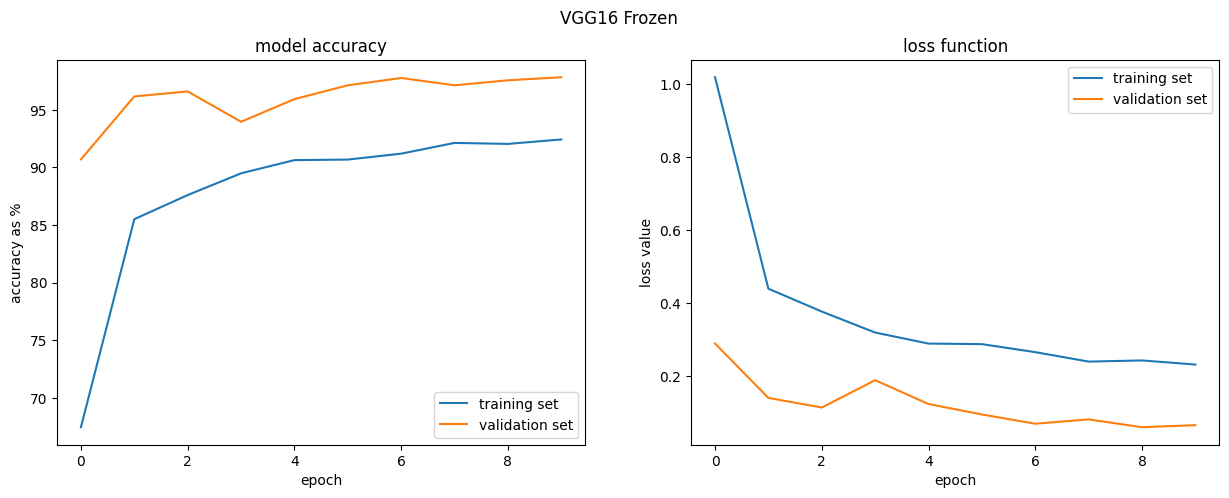

In [ ]:
plot_history(vgg_frozen_history, 'VGG16 Frozen')

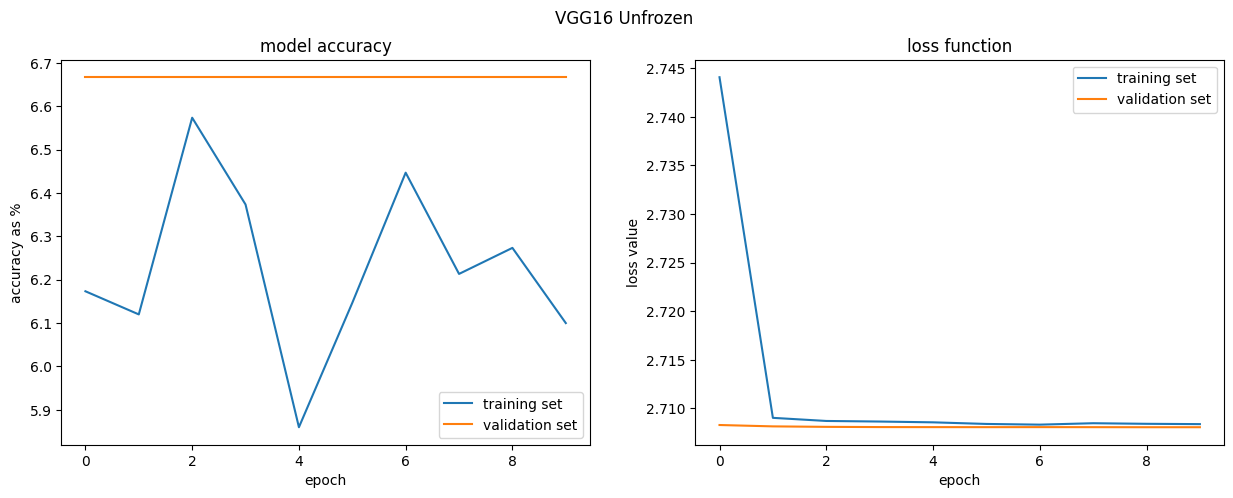

In [ ]:
plot_history(vgg_unfrozen_history, 'VGG16 Unfrozen')

## Confusion matrices



### Estimation from the result
 Based on the accuracy result up above, we should expecte a diagonal in our confusion matrix for the frozen model.

#### Frozen
 Interesting observation is that the model had a relatively larger wrong classification for Papaya. You can see it classified 10 of it into Brinjali. Brinjali is eggplant and in the dataset they are unriped eggplants, which look very similar to the unriped Papaya (can be seen above, there is a few distinguishable features but it can be missleading the shape and colour). Overall misclassified 59 out of 3,000 images.

#### Unfrozen
 When we unfroze the model, the model appears to always guess Tomato, which is why it has a 7% accuracy because it gets 1 out of 15 always right. It misclassified 2,800 out of 3,000.

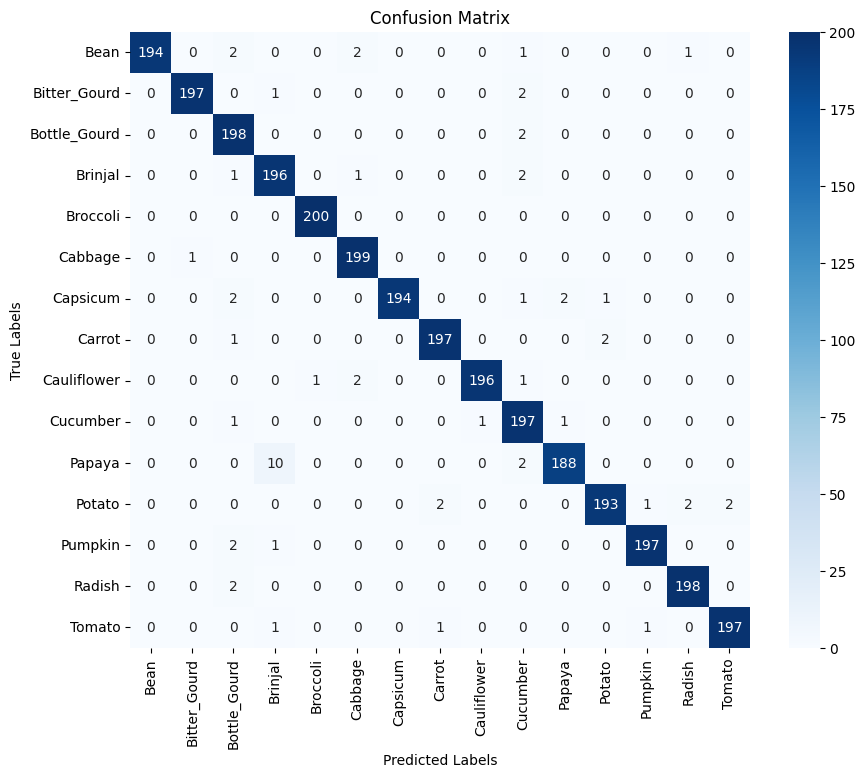

In [ ]:
plot_confusion_matrix(vgg_frozen)

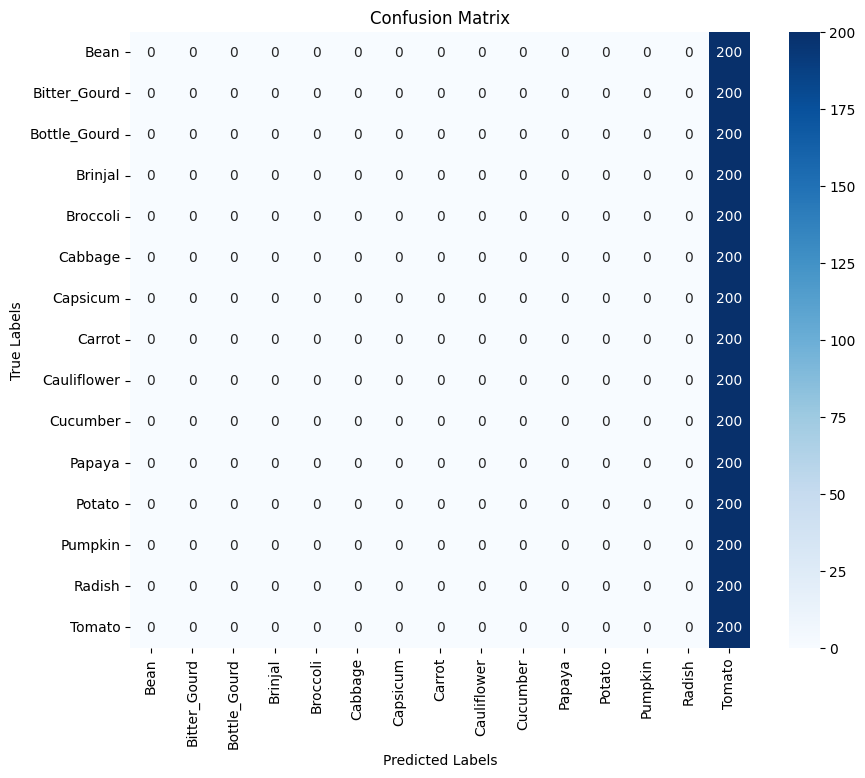

In [ ]:
plot_confusion_matrix(vgg_unfrozen)

# Model 2: InceptionV3  


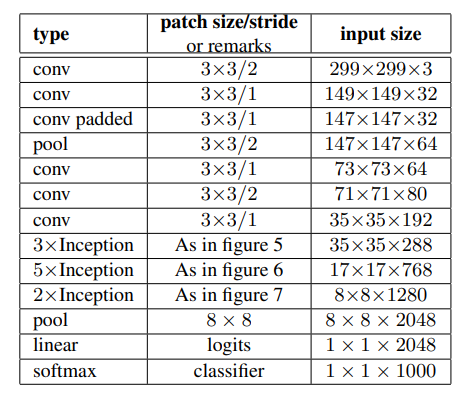


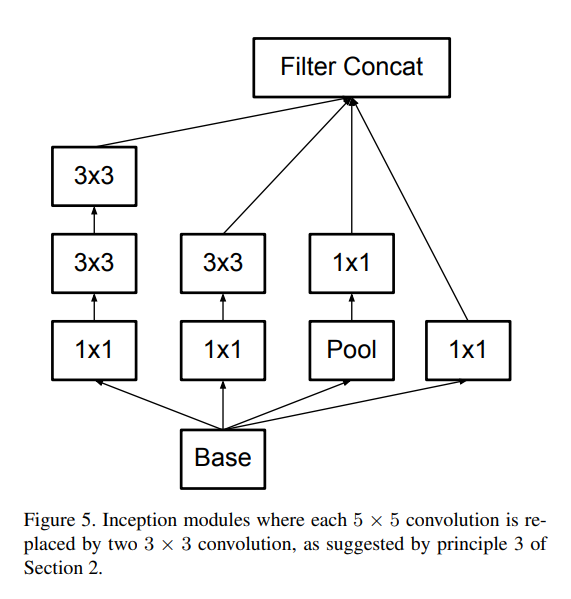
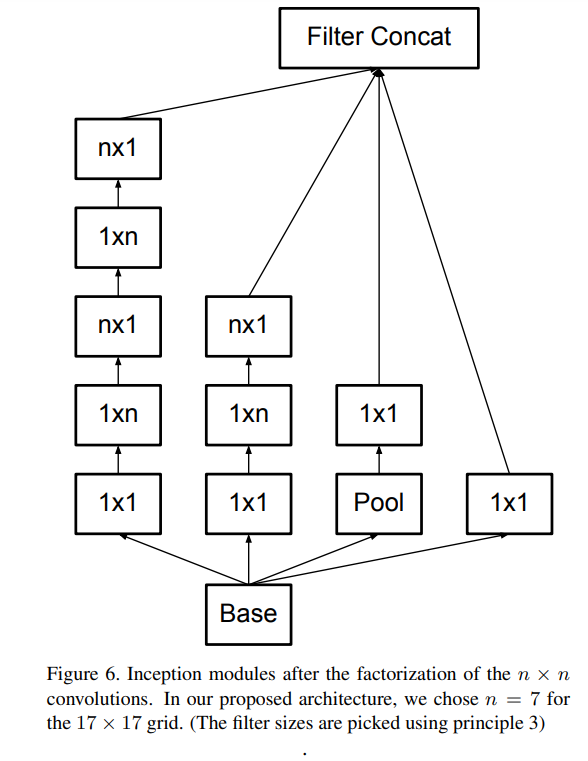

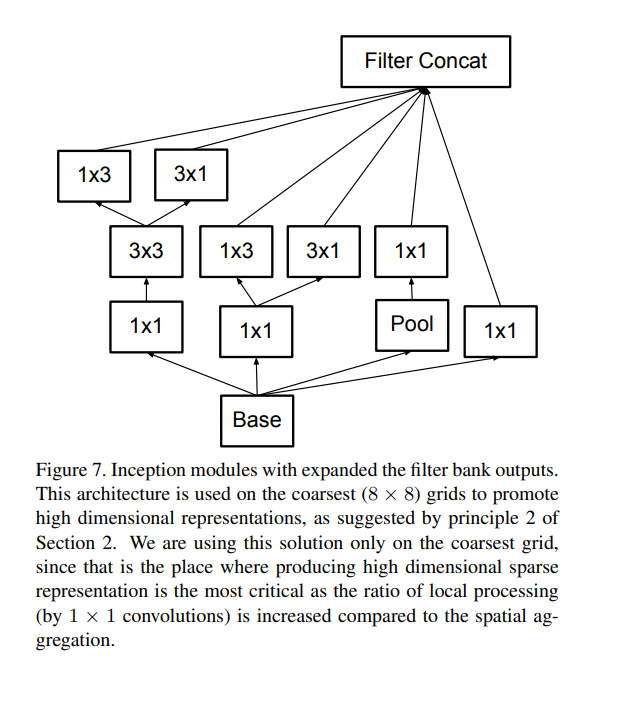

Images above taken from the paper:
Szegedy C. et al (2015) Rethinking the Inception Architecture for Computer Vision - https://arxiv.org/pdf/1512.00567


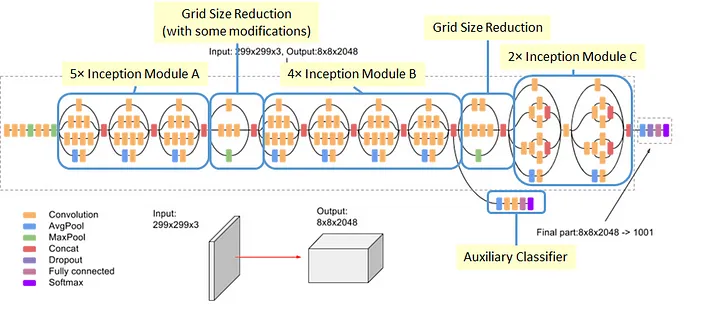

Image taken from: https://sh-tsang.medium.com/review-inception-v3-1st-runner-up-image-classification-in-ilsvrc-2015-17915421f77c


## Architecture


### All taken from Szegedy et. al 2016
Inception-V3 has 42 layers. It is 2.5 times more computational than GoogleLeNet but still more efficient than VGGNet. (Szegedy et al,2016)

Input size: 299x299, 3 channels (RGB image).

- Convolution 3x3, Stride 2
- Convolution 3x3, Stide 1
- Convolution padded 3x3, Stride 1
- Pooling layer 3x3, Stride 2
- Convolution 3x3, Stride 1
- Convolution 3x3, Stride 2
- Convolution 3x3, Stride 1
-	3 Inception modules: focus on initial feature extraction
	- Last one contains grid size reduction
-	5 Inception modules: focus on deeper feature extraction
	- After the 4th one we have auxilary classificaiton
	- Last one contains grid size reduction
-	2 Inception modules: combines features for final classification
- Pooling 8x8
- Fully connected 2048
- Softmax of 1000

## Inception Module A (as per diagram)
As seen in Figure 5. there is two 3x3 Conv layers on the left. This is coming from Inception-V1 where the performance was boosted by replacing a 5x5 layer with two 3x3.

## Inception Module B (as per diagram)
In the paper Szegedy et. al describe this as changing an NxN convolution into asymmetric convolutions (ie: Nx1 followed by an Nx1 conv). As seen in Figure 6, this can give a nice reduction in number of parameters. In the paper they used 7 specifically for their model in this inception module.

## Inception Module C (as per diagram)
Seen below in Figure 9 is a conventional way of downsizing. The authors propose a more efficient way of downsizing, using convolutional operations.

## Auxiliary Classifiers:
In very deep networks to achieve faster convergence by attaching the output to the classifier heads. This is achieved by pushing useful gradients and prevents the effect of vanishing gradient problem. Source: https://paperswithcode.com/method/auxiliary-classifier


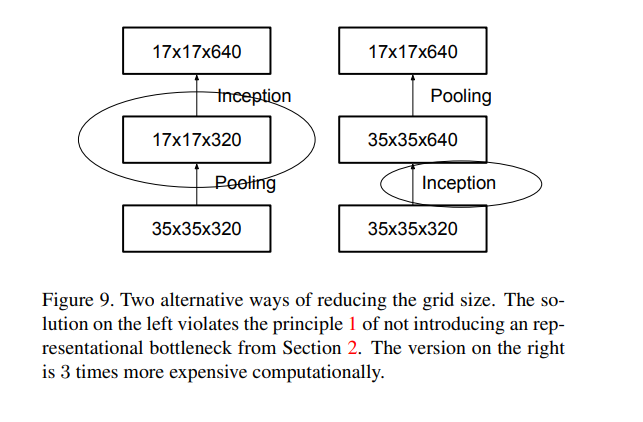

Figure 9. Common way of down sizing

Szegedy, C., Vanhoucke, V., Ioffe, S., Shlens, J. and Wojna, Z., 2016. Rethinking the inception architecture for computer vision. In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 2818-2826).

In [ ]:
# We do the same as earlier except we changed the image sizes

inception_train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{download_path}/train",
    labels=LABLES_TYPE,
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    image_size=INCEPTION_IMG_SIZE, # Image size changed here
    shuffle=True,
    seed=SEED
)

inception_test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{download_path}/test",
    labels=LABLES_TYPE,
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    image_size=INCEPTION_IMG_SIZE, # Image size changed here
    shuffle=True,
    seed=SEED
)

inception_val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{download_path}/validation",
    labels=LABLES_TYPE,
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    image_size=INCEPTION_IMG_SIZE, # Image size changed here
    shuffle=True,
    seed=SEED
)

CLASS_NAMES = inception_train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(CLASS_NAMES)

Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


### Image Augmentation for InceptionV3



In [ ]:
# Taken from: https://www.researchgate.net/profile/Srikanth-Tammina/publication/337105858_Transfer_learning_using_VGG-16_with_Deep_Convolutional_Neural_Network_for_Classifying_Images/links/5dc94c3ca6fdcc57503e6ad9/Transfer-learning-using-VGG-16-with-Deep-Convolutional-Neural-Network-for-Classifying-Images.pdf?_sg%5B0%5D=started_experiment_milestone&origin=journalDetail&_rtd=e30%3D
"""
The following code was used in the paper, however it has now bee
deprecated, we will convert it to a more modern pipeline

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode = 'nearest'
)

test_datagen = ImageGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
"""

# Sequential Augmentation applied to the data
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),                    # Random rotation by upto 36 degrees
    tf.keras.layers.RandomZoom(0.2),                        # Random zoom by upto 20% of
    tf.keras.layers.RandomTranslation(0.2, 0.2),            # Random translation of
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),  # Random flipping images horizontally and vertically
    tf.keras.layers.RandomContrast(0.2),                    # Random contrast adjusment of 20%
])

# Function to be mapped
def apply_augmentation(image, label):
    return data_augmentation(image), label

# See variables starting with inception_
inception_train_ds = inception_train_ds.map(apply_augmentation, num_parallel_calls=AUTOTUNE)

inception_train_ds = inception_train_ds.map(lambda x, y: (x / 255.0, y))
inception_val_ds = inception_val_ds.map(lambda x, y: (x / 255.0, y))
inception_test_ds = inception_test_ds.map(lambda x, y: (x / 255.0, y))

print(f'Train dataset shape: {inception_train_ds.element_spec}')
print(f'Validation dataset shape: {inception_val_ds.element_spec}')

Train dataset shape: (TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))
Validation dataset shape: (TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))


## Inception model
Transfer learning taken from Keras API: https://keras.io/api/applications/inceptionv3/

In [ ]:
def create_inceptionv3_model(
                        learning_rate=0.001,
                        optimizer='adam',
                        activation='relu',
                        dropout_rate=0.5,
                        loss ='categorical_crossentropy',
                        input_shape=INCEPTION_INPUT_SHAPE,
                        frozen = True
) -> Model:
    inception_model = InceptionV3(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
        name="inceptionv3"
    )

    # Frozen convolutions or not
    if frozen:
      for layer in inception_model.layers:
          layer.trainable = False
    else:
      for layer in inception_model.layers:
          layer.trainable = True

    x = inception_model.output
    x = GlobalAveragePooling2D()(x) # Global pooling layer taken from https://stackoverflow.com/questions/44091023/how-to-use-pre-trained-features-from-vgg-16-as-input-to-globalaveragepooling2d
                                    # After we completed training we figured we probably should've used flatten(), but the model ended up running fine
    output = Dense(15, activation='softmax')(x)

    model = Model(inputs=inception_model.input, outputs=output)

    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    return model

print("Inception function created")

Inception function created


## About the model


### Transfer Learning
We leveraged the transfer learning by using the weights on imagenet.

### Optimiser
We will try it with Adam optimizer, however later on we will be experimenting with different hyperparameters

### Loss Function
We will use Categorical Cross Entropy to categorize our classifications

### Metrics
We will be aiming for high accuracy

### The summary
Frozen Convolutions:
Total Parameters: 6.8M.
Trainable Parameters: 0 (frozen during transfer learning).

Unfrozen Convolutions:
Total Parameters: 6.8M.
Trainable Parameters: 6.8M (all layers trainable).

In [ ]:
inception = create_inceptionv3_model()
inception_unfrozen = create_inceptionv3_model(frozen=False)
inception.summary()
inception_unfrozen.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 299, 299, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 149, 149, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 149, 149, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 149, 149, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 147, 147, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 147, 147, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 147, 147, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 147, 147, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 147, 147, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 147, 147, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 73, 73, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 73, 73, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 73, 73, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 73, 73, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 71, 71, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 71, 71, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 21,833,519 (83.29 MB)

 Trainable params: 30,735 (120.06 KB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 299, 299, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_94 (Conv2D)        │ (None, 149, 149, 32)   │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_94    │ (None, 149, 149, 32)   │             96 │ conv2d_94[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_94             │ (None, 149, 149, 32)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_95 (Conv2D)        │ (None, 147, 147, 32)   │          9,216 │ activation_94[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_95    │ (None, 147, 147, 32)   │             96 │ conv2d_95[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_95             │ (None, 147, 147, 32)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_96 (Conv2D)        │ (None, 147, 147, 64)   │         18,432 │ activation_95[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_96    │ (None, 147, 147, 64)   │            192 │ conv2d_96[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_96             │ (None, 147, 147, 64)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 73, 73, 64)     │              0 │ activation_96[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_97 (Conv2D)        │ (None, 73, 73, 80)     │          5,120 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_97    │ (None, 73, 73, 80)     │            240 │ conv2d_97[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_97             │ (None, 73, 73, 80)     │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_98 (Conv2D)   

 Total params: 21,833,519 (83.29 MB)

 Trainable params: 21,799,087 (83.16 MB)

 Non-trainable params: 34,432 (134.50 KB)

## Frozen Convolutions

In [ ]:
inception_history = inception.fit(inception_train_ds, validation_data=inception_val_ds, epochs=10)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 108s 359ms/step - accuracy: 0.7440 - loss: 1.0388 - val_accuracy: 0.9723 - val_loss: 0.1386
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 252ms/step - accuracy: 0.9645 - loss: 0.1672 - val_accuracy: 0.9793 - val_loss: 0.0823
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 251ms/step - accuracy: 0.9770 - loss: 0.1071 - val_accuracy: 0.9900 - val_loss: 0.0541
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 252ms/step - accuracy: 0.9795 - loss: 0.0860 - val_accuracy: 0.9927 - val_loss: 0.0411
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 255ms/step - accuracy: 0.9873 - loss: 0.0621 - val_accuracy: 0.9923 - val_loss: 0.0363
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 251ms/step - accuracy: 0.9849 - loss: 0.0635 - val_accuracy: 0.9940 - val_loss: 0.0310
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 251ms/step - accuracy: 0.9864 - loss: 0.0545 - val_accuracy: 0.9950 - val_loss: 0.0224
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 251ms/step - accuracy: 0.9877 - loss: 

## Unfrozen Convolutions


In [ ]:
inception_unfrozen_history = inception_unfrozen.fit(inception_train_ds, validation_data=inception_val_ds, epochs=10)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 190s 476ms/step - accuracy: 0.8703 - loss: 0.4591 - val_accuracy: 0.7803 - val_loss: 1.0034
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 65s 263ms/step - accuracy: 0.9635 - loss: 0.1234 - val_accuracy: 0.7067 - val_loss: 1.6468
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 67s 274ms/step - accuracy: 0.9787 - loss: 0.0827 - val_accuracy: 0.7517 - val_loss: 1.8843
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 66s 266ms/step - accuracy: 0.9671 - loss: 0.1171 - val_accuracy: 0.8473 - val_loss: 0.7288
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 255ms/step - accuracy: 0.9791 - loss: 0.0699 - val_accuracy: 0.9827 - val_loss: 0.0646
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 257ms/step - accuracy: 0.9851 - loss: 0.0468 - val_accuracy: 0.8720 - val_loss: 0.6137
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 65s 263ms/step - accuracy: 0.9746 - loss: 0.0904 - val_accuracy: 0.9903 - val_loss: 0.0393
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 256ms/step - accuracy: 0.9857 - loss: 

## Saving

### Model

In [ ]:
# Saved location
model_path = '/content/drive/MyDrive/saved_models/'
print("We will save our models to:", model_path)

We will save our models to: /content/drive/MyDrive/saved_models/


In [ ]:
# Save the two trained models for quick retrival later!
inception.save(os.path.join(model_path, 'inceptionv3_frozen.keras'))
inception_unfrozen.save(os.path.join(model_path, 'inceptionv3_unfrozen.keras'))
print("Saved the models")


Saved the models


### History


In [ ]:
# Save the history

with open(os.path.join(model_path, 'lenet_frozen_history.pkl'), 'wb') as file:
    pickle.dump(inception.history, file)

with open(os.path.join(model_path, 'lenet_unfrozen_history.pkl'), 'wb') as file:
    pickle.dump(inception_unfrozen_history.history, file)

print("Saved the history")

Saved the history


## Loading both the model and history

In [ ]:
# Load Models
inception = tf.keras.models.load_model(os.path.join(model_path, 'inceptionv3_frozen.keras'))
inception_unfrozen = tf.keras.models.load_model(os.path.join(model_path, 'inceptionv3_unfrozen.keras'))

# Load histories
inception_history = pickle.load(open(os.path.join(model_path, 'lenet_frozen_history.pkl'), 'rb'))
inception_unfrozen_history = pickle.load(open(os.path.join(model_path, 'lenet_unfrozen_history.pkl'), 'rb'))

print("Loaded models and history")

Loaded models and history


## Plotting


We can see the frozen model has a really good performance and it is not overfitted! However the unfrozen model is not bad, incontrast to VGG16 unfrozen. It is struggling to well fit, little underfit but it is jumping up and down between epochs. Potentially the learning rate is heavily changing the convolution layers and just jumping between local minimas.

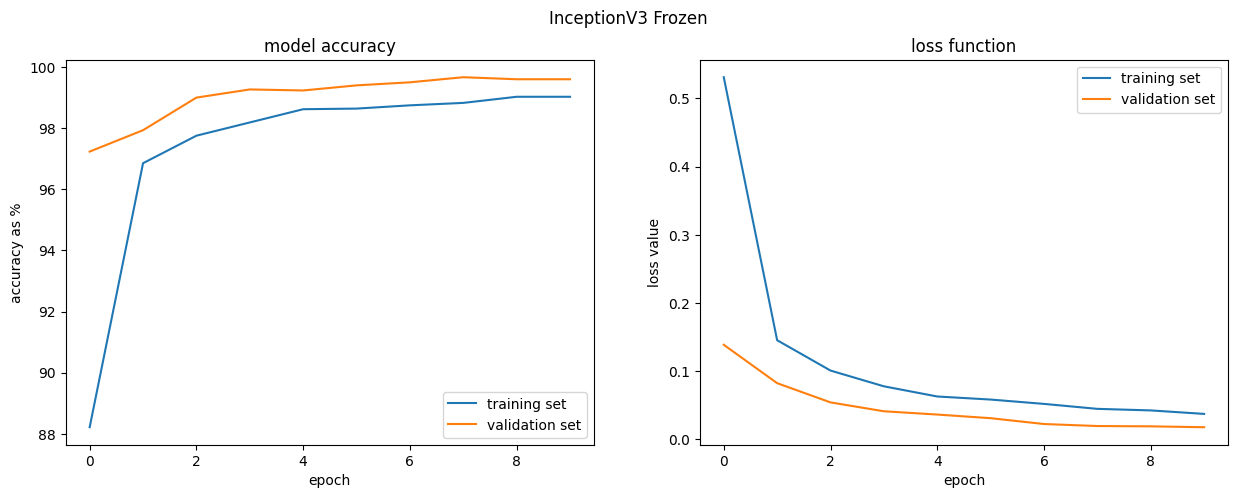

In [ ]:
plot_history(inception_history, 'InceptionV3 Frozen')

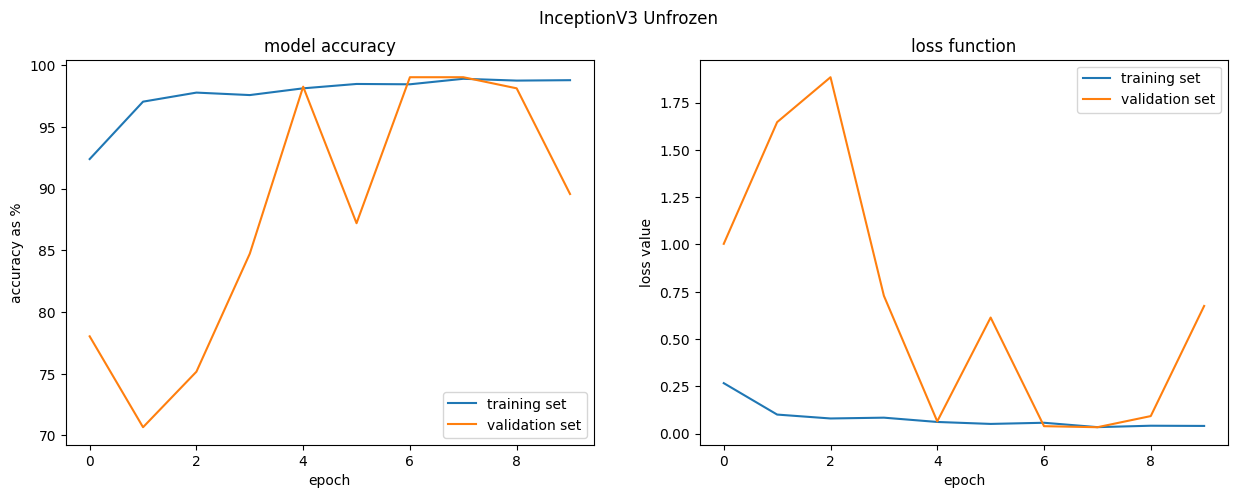

In [ ]:
plot_history(inception_unfrozen_history, 'InceptionV3 Unfrozen')

## Confusion Matrices


### Frozen
The frozen model is very well trained. It is performing better than VGG16 but it has the same issue with Papaya and Brinjali but atleast it is only getting half as much wrong (5 vs 10). The model overall misclassified 23 out of 3,000 vegetables.

### Unfrozen
The model overall did okay, there is a lot of classes it fails to perform well, but it performs in certain classes relatively good. It managed to only miss 3 papayas in cotrast to frozen's 5. What stands out is definitely cucumber, it guesses to be either papaya or brinjali a lot. The model has misclassified 277 out of 3,000 images.

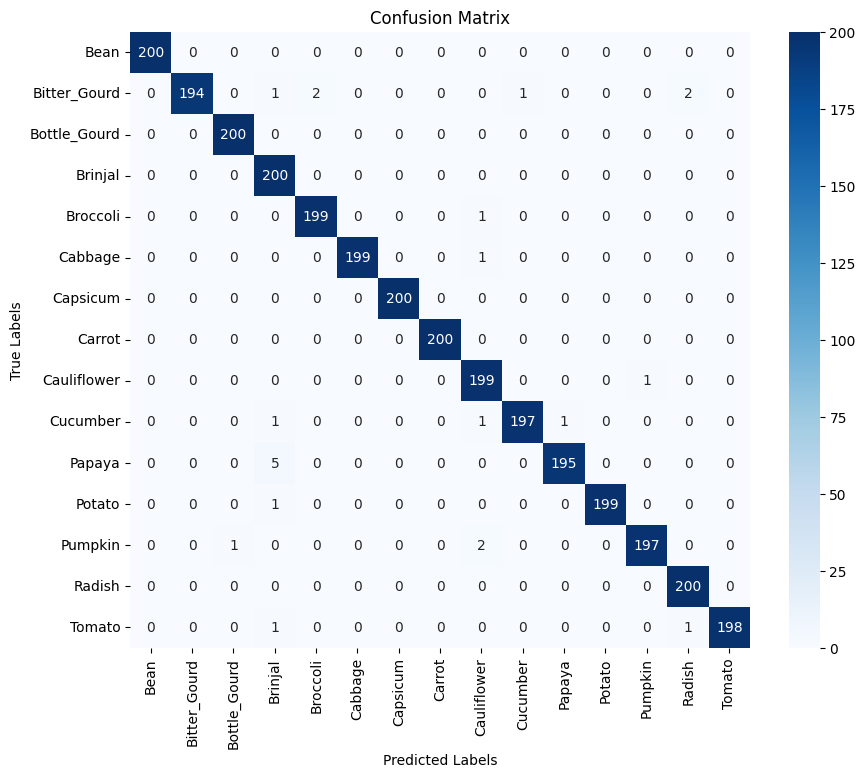

In [ ]:
plot_confusion_matrix(inception, test_set = inception_test_ds)

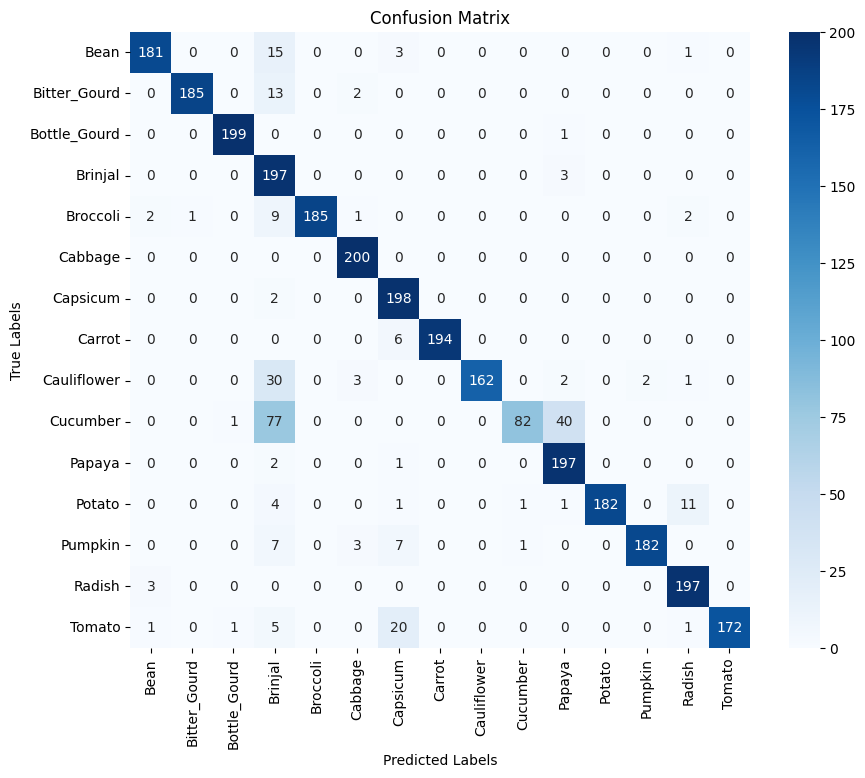

In [ ]:
plot_confusion_matrix(inception_unfrozen, test_set = inception_test_ds)

# Cross Validation



We will create two prallel lists for the file paths and labels. The TensorFlow dataset iterators doesn't allow for splitting it and changing the fold so this is our work around.

In [ ]:
# For cross fold, we will load all the test and validation paths
# And then we will apply stratified K-fold and check the performance with the test data
file_paths = []
labels = []

# We will add the filepaths and labels to two parallel arrays
for class_index, class_name in enumerate(CLASS_NAMES):
    class_path = f"{download_path}/train/{class_name}"

    # Grab all the images and map them to the classificaiton
    for image_path in os.listdir(class_path):
        file_paths.append(f"{class_path}/{image_path}")
        labels.append(class_index)

# Do the same for the Validation data
for class_index, class_name in enumerate(CLASS_NAMES):
    class_path = f"{download_path}/validation/{class_name}"

    # Adding them to the two arrays
    for image_path in os.listdir(class_path):
        file_paths.append(f"{class_path}/{image_path}")
        labels.append(class_index)

# Convert to numpy arrays
file_paths = np.array(file_paths)
labels = np.array(labels)

print("Number of images:", len(file_paths))
print("Sample image path:", file_paths[0])
print("Sample label:", labels[0]) # notice how this is a single integer, we will convert this to one-hot encoding

Number of images: 18000
Sample image path: /root/.cache/kagglehub/datasets/misrakahmed/vegetable-image-dataset/versions/1/Vegetable Images/train/Bean/0249.jpg
Sample label: 0


## K-Fold


Here we have two functions, both load the images, one loads it in 224x224 for VGG and the other in 299x299 for Inception

Then we have the run_K_fold function. It will run K number of times with different folds.

In [ ]:
history_dictionary = {}
N_EPOCHS = 3

INCEPTION = 'Inception'
VGG = 'Vgg-16'
MODEL_NAMES = [INCEPTION, VGG]

# We will load the image from the given path and we will return a tuple of (image, label)
def inception_load_and_preprocess_images(path, label):
  image = tf.io.read_file(path)                       # Read file
  image = tf.image.decode_jpeg(image, channels=3)     # Load it as image
  image = tf.image.resize(image, INCEPTION_IMG_SIZE)  # Scale it to Inception
  image = tf.cast(image, tf.float32) / 255.0          # Standardize it
  label = tf.one_hot(label, 15)                       # Convert the label from numnerical to one-hot encoded
  return image, label

def vgg_load_and_preprocess_images(path, label):
  image = tf.io.read_file(path)                       # Read file
  image = tf.image.decode_jpeg(image, channels=3)     # Load it as image
  image = tf.image.resize(image, IMG_SIZE)            # Scale it to VGG
  image = tf.cast(image, tf.float32) / 255.0          # Standardize it
  label = tf.one_hot(label, 15)                       # Convert the label from numnerical to one-hot encoded
  return image, label

def run_K_fold(K, file_paths, labels, model_constructor, model_name):
  print(f"Running K fold with K={K} for model={model_name}")

  # Initialize our Kfold
  skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

  # We add the model name to the dictionary if not already existing. We will retain our history via model_name -> [fold histories]
  if model_name not in history_dictionary:
    history_dictionary[model_name] = []

  # We will retain our history of training
  fold_histories = []

  # We will iterate through our kfold splits
  for fold_num, (train_index, val_index) in enumerate(skf.split(file_paths, labels)):
    print(f"Fold {fold_num + 1}/{K}")

    # Get the iterators for our dataset
    X_train, X_val = file_paths[train_index], file_paths[val_index]
    y_train, y_val = labels[train_index], labels[val_index]

    # Convert to TensorFlow dataset
    train_ds_kfold = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    val_ds_kfold = tf.data.Dataset.from_tensor_slices((X_val, y_val))

    # We will apply data transformation (normalize and loading it from the disk)
    if model_name == INCEPTION: # Two different functions, one for rescale 299x299 the other to 224x224
      train_ds_kfold = train_ds_kfold.map(inception_load_and_preprocess_images, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
      val_ds_kfold = val_ds_kfold.map(inception_load_and_preprocess_images, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    else:
      train_ds_kfold = train_ds_kfold.map(vgg_load_and_preprocess_images, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
      val_ds_kfold = val_ds_kfold.map(vgg_load_and_preprocess_images, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)

    model = model_constructor() # Create a new model
    k_fold_history = model.fit(train_ds_kfold, validation_data=val_ds_kfold, epochs=N_EPOCHS) # Train the model on current K-fold

    fold_histories.append(k_fold_history.history) # Append the history of the model

  # At the end of the K-Fold training we will add the list of histories to the dict
  save_filename = f"{model_name}_K{K}_fold{fold_num + 1}.keras"
  save_location = os.path.join(model_path, f'k_folds-{K}')
  os.makedirs(save_location, exist_ok=True)
  model.save(os.path.join(save_location, save_filename)) # Save the model

  print(f"Model saved at {save_location}")

  history_dictionary[model_name].append(fold_histories) # We will retain all the histories

print("Functions created:", inception_load_and_preprocess_images, vgg_load_and_preprocess_images, run_K_fold)

Functions created: <function inception_load_and_preprocess_images at 0x782919c31b40> <function vgg_load_and_preprocess_images at 0x782919c31bd0> <function run_K_fold at 0x782919c31c60>


## Cross fold for both Inception and VGG

In [ ]:
K_values = [3]

# For each model, we will train on each K-fold provided in the list above
for model_name in MODEL_NAMES:
  for k in K_values:
    if model_name == INCEPTION:
      model_constructor = create_inceptionv3_model
    else:
      model_constructor = create_vgg16_model

    run_K_fold(k, file_paths, labels, model_constructor, model_name)



# Save the history
with open("history_of_k_folds.pkl", 'wb') as file:
    pickle.dump(history_dictionary, file)

print("History dictionary saved as history_of_k_folds.pkl")

Running K fold with K=3 for model=Inception
Fold 1/3
Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 131ms/step - accuracy: 0.1979 - loss: 4.5198 - val_accuracy: 0.7248 - val_loss: 0.9917
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6122 - loss: 1.1845 - val_accuracy: 0.8910 - val_loss: 0.3873
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8697 - loss: 0.4621 - val_accuracy: 0.9390 - val_loss: 0.2348
Fold 2/3
Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 131ms/step - accuracy: 0.1945 - loss: 4.6548 - val_accuracy: 0.7110 - val_loss: 1.0458
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.5805 - loss: 1.3188 - val_accuracy: 0.8858 - val_loss: 0.4031
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8639 - loss: 0.4756 - val_accuracy: 0.9402 - val_loss: 0.2441
Fold 3/3
Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.2106 - loss: 4.5906 - val_accuracy: 0.7193 - val_loss: 0.9995
Epoch 2/3
188/188 ━━━━━━━━━

In [ ]:
# Load history
with open("history_of_k_folds.pkl", 'rb') as file:
    history_dictionary = pickle.load(file)

print(history_dictionary)

{'Inception': [[{'accuracy': [0.11808333545923233, 0.5941666960716248, 0.8098333477973938], 'loss': [5.515444755554199, 1.3797028064727783, 0.6446232199668884], 'val_accuracy': [0.7428333163261414, 0.8820000290870667, 0.9359999895095825], 'val_loss': [0.9851544499397278, 0.4053805470466614, 0.23971234261989594]}, {'accuracy': [0.8804166913032532, 0.9183333516120911, 0.9361666440963745], 'loss': [0.3923150300979614, 0.27061927318573, 0.21254463493824005], 'val_accuracy': [0.9564999938011169, 0.9626666903495789, 0.965499997138977], 'val_loss': [0.1778045892715454, 0.14786477386951447, 0.12771371006965637]}, {'accuracy': [0.9428333044052124, 0.9517499804496765, 0.9615833163261414], 'loss': [0.1856064796447754, 0.1575431376695633, 0.13135947287082672], 'val_accuracy': [0.9768333435058594, 0.9801666736602783, 0.9833333492279053], 'val_loss': [0.09080536663532257, 0.07828007638454437, 0.06793046742677689]}]], 'Vgg-16': [[{'accuracy': [0.2848333418369293, 0.28308331966400146, 0.21483333408832

### Evaluation



#### Averaging the results
Visualizing what is in the dictionary

In [ ]:
# Due to the way we appended our data, we have a list in a list. So we will
# iterate through the dict and then get the [0] to get our list which we accidentally appended

#   (key, value) =
#   (model, [history_list])
for (key, value) in history_dictionary.items():
  print(key)
  for fold_histories in value[0]:
    print(fold_histories) # Visual representation

Inception
{'accuracy': [0.1146666631102562, 0.6114166378974915, 0.8195833563804626], 'loss': [5.409435749053955, 1.3203880786895752, 0.6154788136482239], 'val_accuracy': [0.7248333096504211, 0.890999972820282, 0.9390000104904175], 'val_loss': [0.9917280077934265, 0.3872705399990082, 0.23480398952960968]}
{'accuracy': [0.10366666316986084, 0.5861666798591614, 0.815416693687439], 'loss': [5.585639953613281, 1.4325377941131592, 0.6316346526145935], 'val_accuracy': [0.7110000252723694, 0.8858333230018616, 0.9401666522026062], 'val_loss': [1.045769214630127, 0.40308505296707153, 0.2440861016511917]}
{'accuracy': [0.12266666442155838, 0.5809166431427002, 0.8073333501815796], 'loss': [5.431990623474121, 1.4756429195404053, 0.642185389995575], 'val_accuracy': [0.7193333506584167, 0.8813333511352539, 0.9348333477973938], 'val_loss': [0.9995280504226685, 0.4099244773387909, 0.23823563754558563]}
Vgg-16
{'accuracy': [0.2900833189487457, 0.2527500092983246, 0.2069166600704193], 'loss': [4.65876483

#### Getting the average

In [ ]:
inception_accuracies = []
vgg_accuracies = []

inception_val_accuracies = []
vgg_val_accuracies = []

for (key, value) in history_dictionary.items(): # Iterate through the dict
  for fold_histories in value[0]:               # From the value, get the single list which we appended

    if key == INCEPTION: # If its inception key, we append to our inception accuracies
      # Get final accuracies
      inception_last_acc = fold_histories['accuracy'][-1]
      inception_last_val_acc = fold_histories['val_accuracy'][-1]

      # Append to our history
      inception_accuracies.append(inception_last_acc)
      inception_val_accuracies.append(inception_last_val_acc)

    elif key == VGG: # Similarly for VGG
      vgg_last_acc = fold_histories['accuracy'][-1]
      vgg_last_val_acc = fold_histories['val_accuracy'][-1]

      vgg_accuracies.append(vgg_last_acc)
      vgg_val_accuracies.append(vgg_last_val_acc)

print("Inception accuracies:", inception_accuracies)
print("VGG accuracies:", vgg_accuracies)

Inception accuracies: [0.8195833563804626, 0.815416693687439, 0.8073333501815796]
VGG accuracies: [0.2069166600704193, 0.10216666758060455, 0.08933333307504654]


In [ ]:
# Averaging
# Mean = Sum of values / number of values
inception_average_accuracy = sum(inception_accuracies) / len(inception_accuracies)
vgg_average_accuracy = sum(vgg_accuracies) / len(vgg_accuracies)

inception_average_val_accuracy = sum(inception_val_accuracies) / len(inception_val_accuracies)
vgg_average_val_accuracy = sum(vgg_val_accuracies) / len(vgg_val_accuracies)

print("Inception average accuracy:", inception_average_accuracy)
print("VGG average accuracy:", vgg_average_accuracy)

print("Inception average validation accuracy:", inception_average_val_accuracy)
print("VGG average validation accuracy:", vgg_average_val_accuracy)

Inception average accuracy: 0.8141111334164938
VGG average accuracy: 0.1328055535753568
Inception average validation accuracy: 0.9380000034968058
VGG average validation accuracy: 0.07050000131130219


#### Evaluation from the numbers


##### InceptionV3
- Inception average accuracy: 0.8141111334164938
- Inception average validation accuracy: 0.9380000034968058

##### VGG16
- VGG average accuracy: 0.1328055535753568
- VGG average validation accuracy: 0.07050000131130219



We can see InceptionV3 performs well, and it does not overfit (Val_Acc > Acc). We could nearly argue that it would be fine to train the model on 3 folds (12,000 training data, 6,000 validation)

On the other-hand, VGG16 has a terrible accuracy. Not only that, but it has a downward trend on learning. This could mean that the model is under fitting, but we disagree with that conclusion because of the downward trend, it appears that it just does negative learning. If it was a binary classification this could be fixed.  

We feel like there might be a logical flaw with how the data is passed in or loaded. It is a bit difficult to see it due the only difference between the two image loaders are the image sizes: 224x224 vs 299x299.

#### Plotting for visalizing the Cross Validation


You can see over epochs how the two models perform. The first graph is the InceptionV3 and the second is VGG16.

We can see inception performs very well. One thing we wish to change for future references is to run it for potentially more epochs (5 or 10) but for now just went with 3 so we can do run both models within reasonable time. Also to test for other folds such as 10. Since earlier we trained the models and we gave 15,000 train and 3,000 validation, that ends up being a 6 fold over 18,000 images.

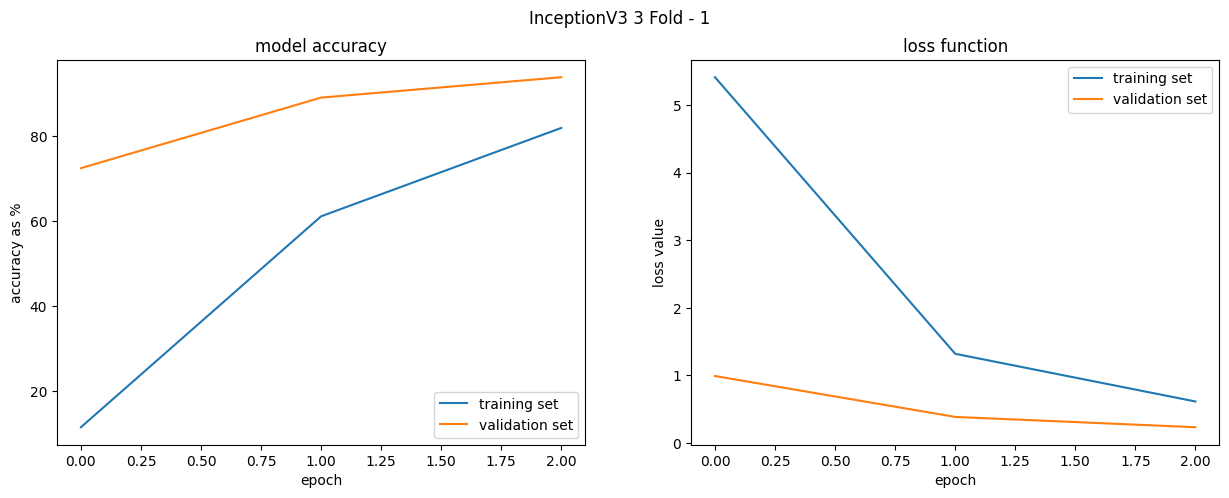

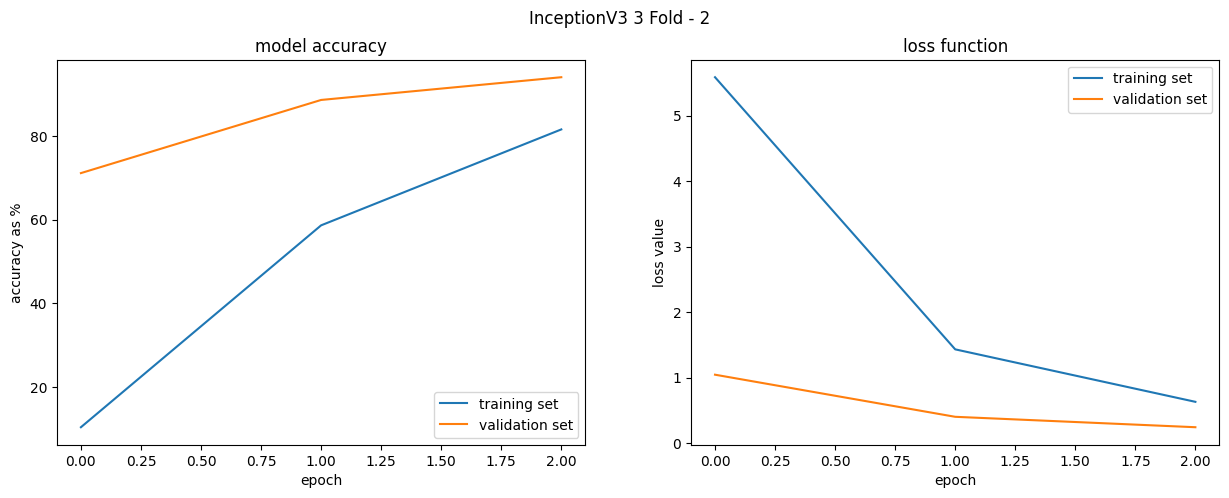

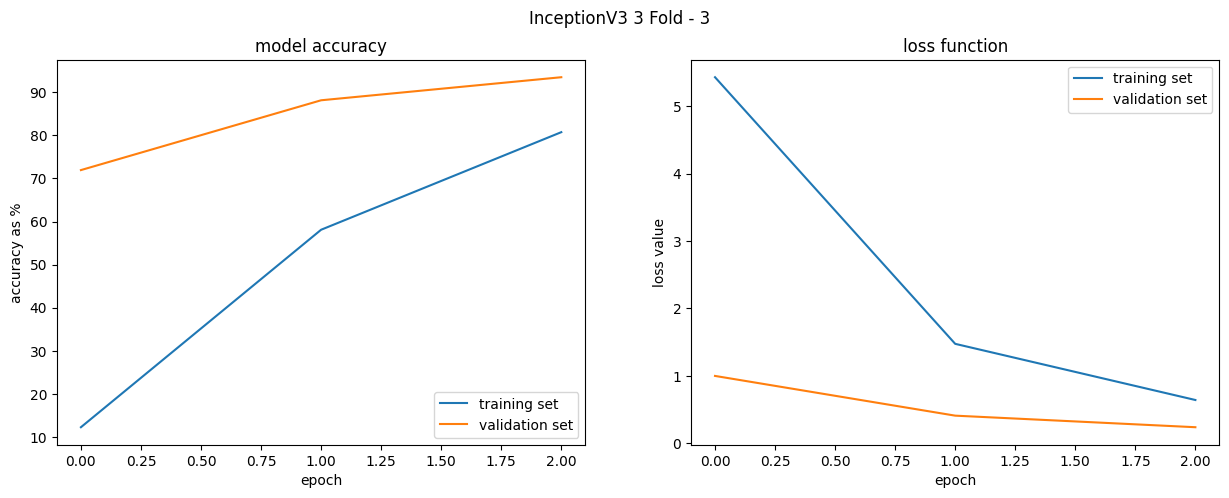

In [ ]:
# Plot inception history
inception_data = history_dictionary[INCEPTION]
for i, model_history_data in enumerate(inception_data):
  for j, history_data in enumerate(model_history_data):
    plot_history(history_data, f'InceptionV3 3 Fold - {j + 1}')

#### VGG History
Please ignore the typo in the graphs, this is the VGG model as indicated by the list accessor.

As you can see over each epoch it has low accuracy and low loss. It makes a lot of small errors (Martin 2024).


Martin Riva 2024, Interpretation of Loss and Accuracy for a Machine Learning Model accessed on 17 Nov 2024: https://www.baeldung.com/cs/ml-loss-accuracy#:~:text=But%2C%20if%20both%20loss%20and,would%20be%20the%20ideal%20case.

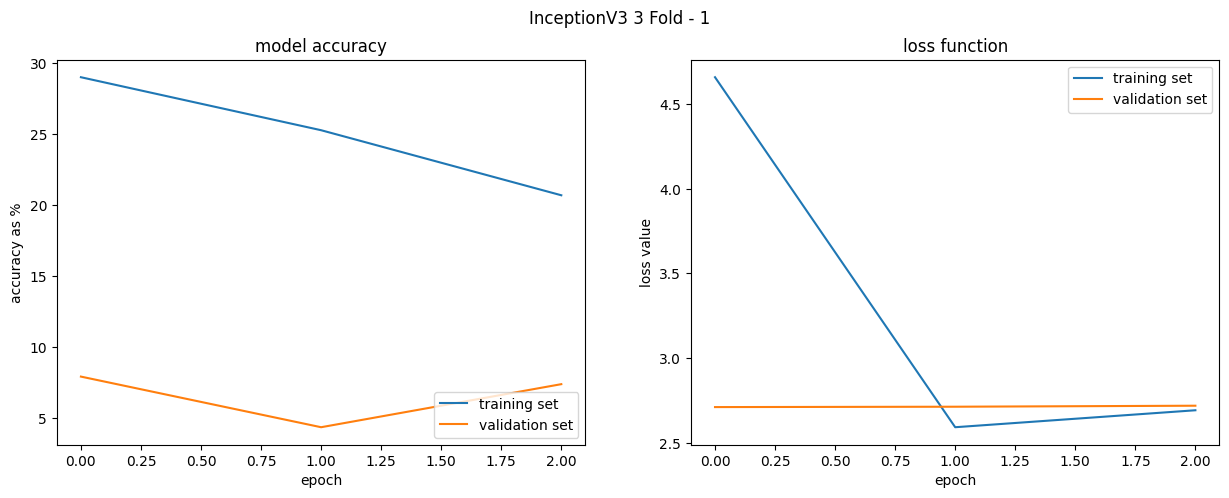

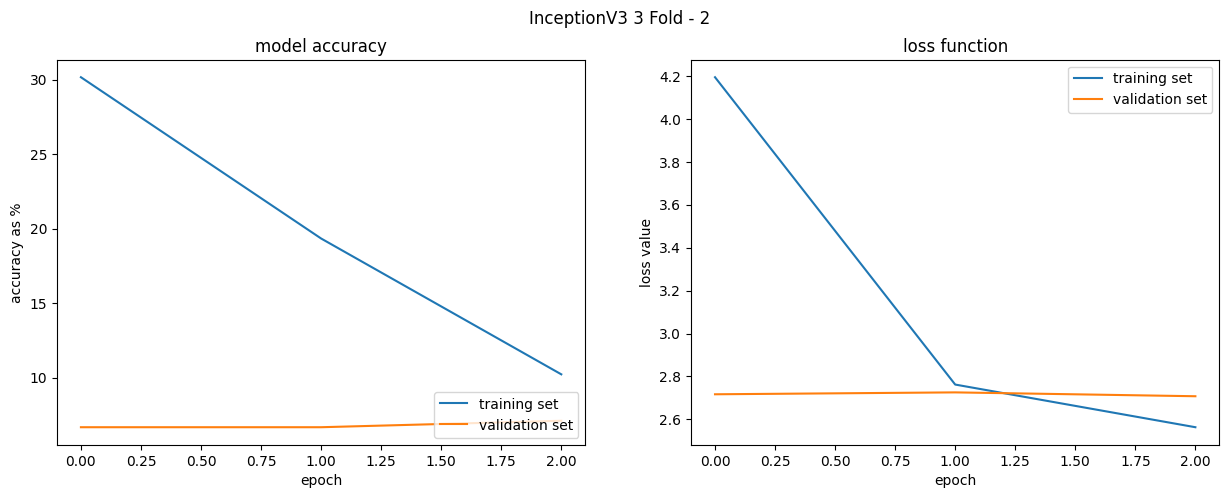

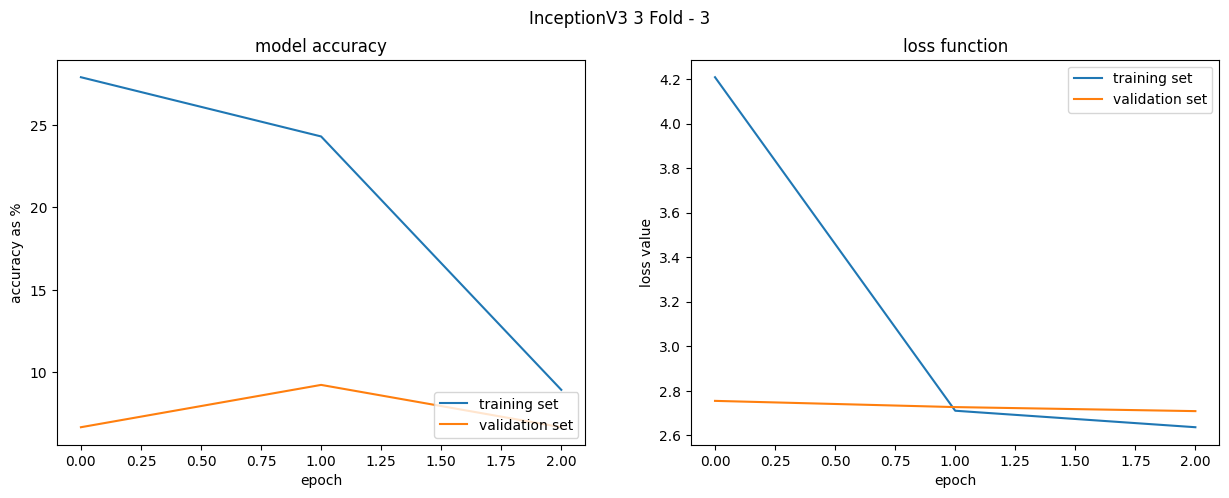

In [ ]:
# Plot inception history
vgg_data = history_dictionary[VGG]
for i, model_history_data in enumerate(vgg_data):
  for j, history_data in enumerate(model_history_data):
    plot_history(history_data, f'InceptionV3 3 Fold - {j + 1}')

# Varying Hyperparameters





Help taken from the TensorFlow documentation: https://www.tensorflow.org/tutorials/keras/keras_tuner

In [ ]:
# First we install the keras tuner from the docs
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.0 MB/s eta 0:00:00


## Hypertuning models


We will hypertune the following:
- Fully connected layers
- Optimizers
- Learning rates

### VGG


You can see in the VGG builder we are pulling a fresh model and freeze the convolution layers. We will have 2 dense layers, startin at 2048 and increase by 1024 upto 4096.

Learning rates we have 0.01, 0.001 and 0.0001

Optimizers we are going to compare Lion against Adam. From the first assignment Milan has tested Lion and this is what his group found about Lion:


> - Lion - evoLved sIgn mOmeNtum optimiser, discovered by Google Brain, and it is claimed to perform better than AdamW. It is a version of SGD that controls the magnitude of the update. This makes Lion memory efficient and faster convergence than Adam.
- Github that implements lion: https://github.com/lucidrains/lion-pytorch  
- Keras documentation that gives a brief overview on Lion: https://keras.io/api/optimizers/lion/




Looking to see how they will perform


### Inception


For inception we will do the same but we will modify a few things:
- For dense layers we will start at lower 1024 for both layers, upto 4096
- We will also try and compare RSMProps
RMSProp - Root Mean Square Propagation is an unpublished optimizer by Geoff Hinton. "The motivation is that the magnitude of gradients can differ for different weights, and can change during learning, making it hard to choose a single global learning rate. RMSProp tackles this by keeping a moving average of the squared gradient and adjusting the weight updates by this magnitude." quote from: PapersWithCode.com ND, available: https://paperswithcode.com/method/rmsprop#:~:text=RMSProp%20is%20an%20unpublished%20adaptive,a%20single%20global%20learning%20rate

In [ ]:
# Following the documentation we are going to create two model builders, one for VGG and another for Inception

# We will use relu as our activations
activation = 'relu'

def vgg_model_builder(hp):
    vgg_model = vgg16.VGG16(
      include_top=False,
      weights="imagenet",
      name="vgg16",
      input_shape=INPUT_SHAPE
    )

    # Freeze the convolution layers
    for layer in vgg_model.layers:
        layer.trainable = False

    x = vgg_model.output

    # Hypertuning the dense layer
    hp_units1 = hp.Int('units1', min_value=2048, max_value=4096, step=1024)
    hp_units2 = hp.Int('units2', min_value=2048, max_value=4096, step=1024)

    x = GlobalAveragePooling2D()(x)
    x = Dense(hp_units1, activation=activation)(x)
    x = Dropout(0.5)(x)
    x = Dense(hp_units2, activation=activation)(x)
    x = Dropout(0.5)(x)
    output = Dense(15, activation='softmax')(x)  # Final layer for 15 classes

    # Hypertuning the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    # Hypertuning the optimizer (randomly select one)
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'lion'])
    if hp_optimizer == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    elif hp_optimizer == 'lion':
        optimizer = keras.optimizers.Lion(learning_rate=hp_learning_rate)

    model = Model(inputs=vgg_model.input, outputs=output)

    # Compile the model
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model


# Inception Model Builder
def inception_model_builder(hp):
    inception_model = InceptionV3(
            include_top=False,
            weights="imagenet",
            input_shape=INCEPTION_INPUT_SHAPE,
            name="inceptionv3"
        )

    # Freeze the convolution layers
    for layer in inception_model.layers:
        layer.trainable = False

    x = inception_model.output

     # Hypertuning the dense layer
    hp_units1 = hp.Int('units1', min_value=1024, max_value=4096, step=1024)
    hp_units2 = hp.Int('units2', min_value=1024, max_value=4096, step=1024)

    x = GlobalAveragePooling2D()(x)
    x = Dense(hp_units1, activation=activation)(x)
    x = Dropout(0.5)(x)
    x = Dense(hp_units2, activation=activation)(x)
    x = Dropout(0.5)(x)
    output = Dense(15, activation='softmax')(x)  # Final layer for 15 classes

    # Hypertuning the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    # Hypertuning the optimizer (randomly select one)
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop', 'lion'])
    if hp_optimizer == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    elif hp_optimizer == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=hp_learning_rate)
    elif hp_optimizer == 'lion':
        optimizer = keras.optimizers.Lion(learning_rate=hp_learning_rate)

    model = Model(inputs=inception_model.input, outputs=output)

    # Compile the model
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

print("Model builders initialised!")

Model builders initialised!


## Now we vary the hyperparameters




We are going to train the models for 10 epochs.

In the documentation, the hyperband function creates a championship styled training. It trains varied models in groups for a few epochs, saves the weights and then chooses the best performing halves and then puts them into a different groups. Now from what we noticed there is a factor of randomization so it doesn't fully explore the variation tree.

Help from https://www.tensorflow.org/tutorials/keras/keras_tuner

### Hypertuning VGG

In [ ]:
import keras_tuner as kt

tuner1 = kt.Hyperband(
    vgg_model_builder,
    objective='val_accuracy', # We are aiming for val_accuracy
    max_epochs=5,             # Train for 5 epochs
    factor=3,
    directory='my_dir',
    project_name='intro_to_kt'
)

# Note: Train_ds has been augmented
tuner1.search(train_ds, epochs=10, validation_data=val_ds)

# Get the optimal hyperparameters
best_hps=tuner1.get_best_hyperparameters(num_trials=1)[0]

Trial 10 Complete [00h 03m 09s]
val_accuracy: 0.9613333344459534

Best val_accuracy So Far: 0.9756666421890259
Total elapsed time: 00h 20m 44s


Screenshots from training:
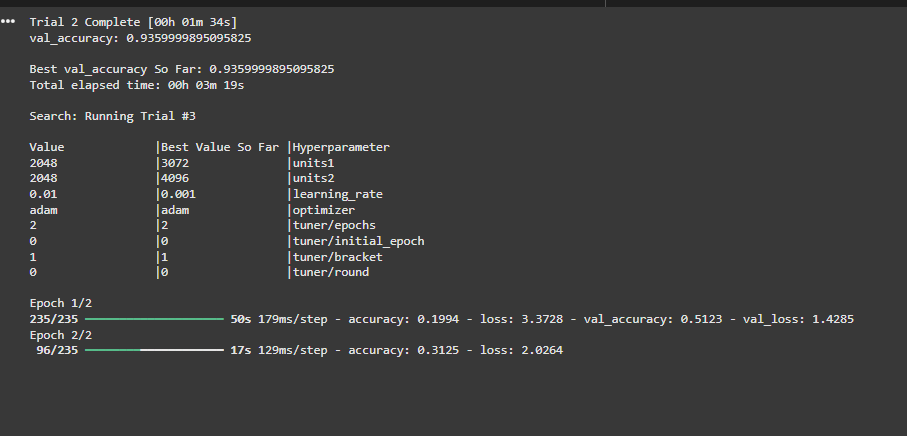

You can see what is being currently trained and what is the best setting found  so far:
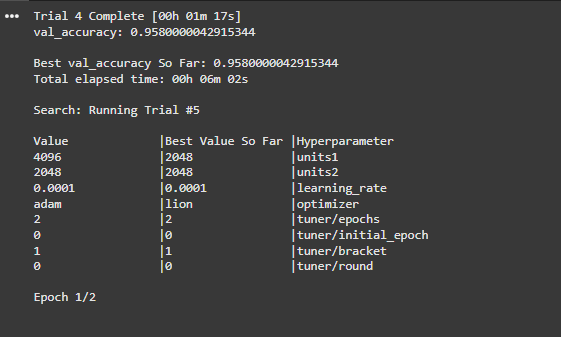

In [ ]:
# Directly from the documentation: https://www.tensorflow.org/tutorials/keras/keras_tuner
print(f"""
The hyperparameter search is complete. The optimal number of units in the densely-connected
layers is {best_hps.get('units1')}, and {best_hps.get('units2')}, the optimal learning rate for {best_hps.get('optimizer')}
is {best_hps.get('learning_rate')}.
""")



The hyperparameter search is complete. The optimal number of units in the densely-connected
layers is 2048, and 2048, the optimal learning rate for lion
is 0.0001.



In [ ]:
# Taken from https://www.tensorflow.org/tutorials/keras/keras_tuner
best_vgg_model = tuner1.hypermodel.build(best_hps)
history = best_vgg_model.fit(train_ds, epochs=10, validation_data=val_ds)

val_acc_per_epoch = history.history['val_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch for VGG: %d' % (best_epoch,))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 151ms/step - accuracy: 0.3561 - loss: 2.0148 - val_accuracy: 0.8917 - val_loss: 0.3589
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 142ms/step - accuracy: 0.8377 - loss: 0.5130 - val_accuracy: 0.9573 - val_loss: 0.1459
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 144ms/step - accuracy: 0.8985 - loss: 0.3132 - val_accuracy: 0.9677 - val_loss: 0.1100
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 144ms/step - accuracy: 0.9179 - loss: 0.2586 - val_accuracy: 0.9723 - val_loss: 0.0927
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 142ms/step - accuracy: 0.9194 - loss: 0.2520 - val_accuracy: 0.9757 - val_loss: 0.0800
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 144ms/step - accuracy: 0.9250 - loss: 0.2322 - val_accuracy: 0.9773 - val_loss: 0.0741
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 143ms/step - accuracy: 0.9197 - loss: 0.2494 - val_accuracy: 0.9747 - val_loss: 0.0777
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 142ms/step - accuracy: 0.9289 - loss: 0

#### Results:
With Lion optimizer, 0.0001 learning rate and two 2,048 fully connected layer we achieved 98.5% Val_accuracy. Not too bad :D

In the graph we can see it has very well fitted. Low loss and high validation accuracy.

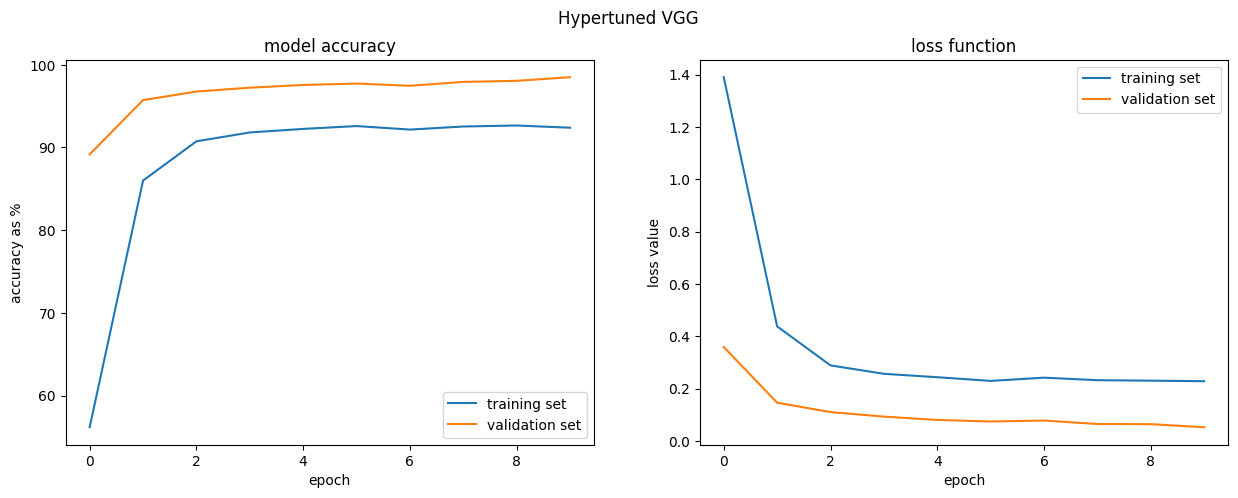

In [ ]:
plot_history(history.history, 'Hypertuned VGG')

## Hypertuning Inception


Lets do the same as above

In [ ]:
import keras_tuner as kt

tuner2 = kt.Hyperband(
    inception_model_builder,
    objective='val_accuracy', # We are aiming for accuracy
    max_epochs=5,             # Train for 5 epochs
    factor=3,
    directory='my_dir',
    project_name='intro_to_kt'
)

# Data is augmented
tuner2.search(inception_train_ds, epochs=10, validation_data=inception_val_ds)

Trial 10 Complete [00h 05m 53s]
val_accuracy: 0.9933333396911621

Best val_accuracy So Far: 0.9933333396911621
Total elapsed time: 00h 39m 23s


In [ ]:
# Directly from the documentation: https://www.tensorflow.org/tutorials/keras/keras_tuner
best_hps=tuner2.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is {best_hps.get('units1')}, second {best_hps.get('units2')}, optimizer = {best_hps.get('optimizer')} and the optimal learning rate for the optimizer
is {best_hps.get('learning_rate')}.
""")


The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is 4096, second 4096, optimizer = lion and the optimal learning rate for the optimizer
is 0.0001.



In [ ]:
model = tuner2.hypermodel.build(best_hps)
history = model.fit(inception_train_ds, epochs=10, validation_data=inception_val_ds)

val_acc_per_epoch = history.history['val_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch for Inception: %d' % (best_epoch,))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 92s 322ms/step - accuracy: 0.7645 - loss: 0.8332 - val_accuracy: 0.9830 - val_loss: 0.0496
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 254ms/step - accuracy: 0.9505 - loss: 0.1638 - val_accuracy: 0.9877 - val_loss: 0.0404
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 65s 263ms/step - accuracy: 0.9541 - loss: 0.1449 - val_accuracy: 0.9867 - val_loss: 0.0454
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 254ms/step - accuracy: 0.9525 - loss: 0.1657 - val_accuracy: 0.9913 - val_loss: 0.0324
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 253ms/step - accuracy: 0.9503 - loss: 0.1642 - val_accuracy: 0.9920 - val_loss: 0.0282
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 252ms/step - accuracy: 0.9526 - loss: 0.1602 - val_accuracy: 0.9893 - val_loss: 0.0331
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 253ms/step - accuracy: 0.9468 - loss: 0.1739 - val_accuracy: 0.9933 - val_loss: 0.0274
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 64s 262ms/step - accuracy: 0.9429 - loss: 0

#### Results
Once again, Lion optimizer and we ended up with two 4,096 layers with 0.0001 learning rate. We achieved 99.33% Val_accuracy! Even better 😀

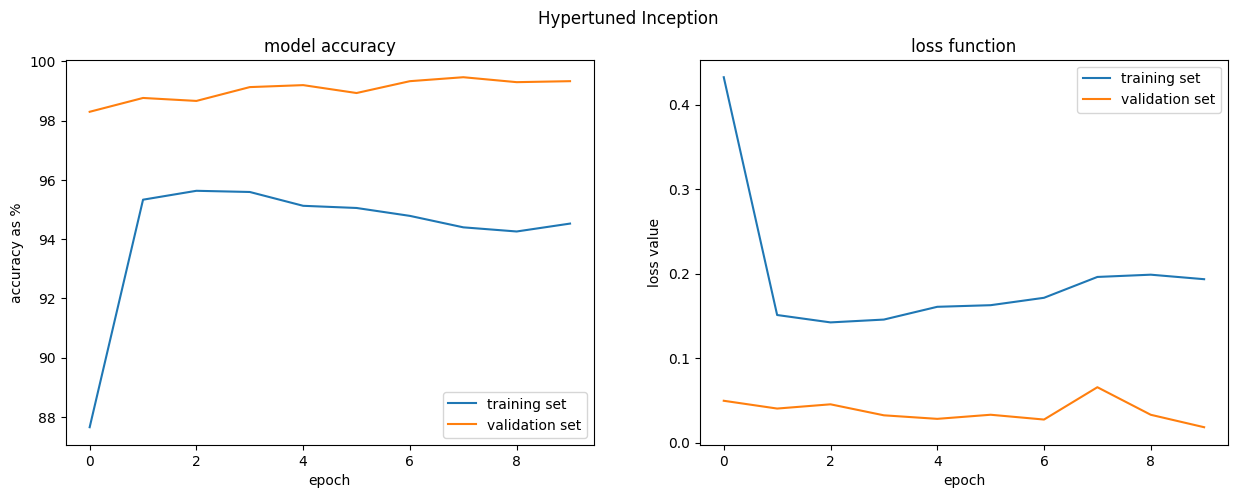

In [ ]:
plot_history(history.history, 'Hypertuned Inception')